# Synthetic Track Generation and Day-Night Merging Pipeline

## Overview
This document outlines the workflow for generating synthetic Clear Sky Index (CSI) estimation during nighttime with GUM Generator. By applying the GUM to nocturnal satellite bands and subsequently merging these estimation with daytime ground-truth CAMS data, the pipeline constructs a continuous and hourly time series.

---

## 1. Model Initialization and Data Loading
The pipeline initializes the pre-trained GUM model and prepares the global normalization metrics required for inference.

* **Model Checkpoint:** `Model_checkpoint/best_gum.pt`
* **Model Configuration:** `GUM(feature_size=64, K=2, gate_temp=0.5)`
* **Normalization Stats:** Loaded from `Data/static/minmax_strat.npz` (calculated exclusively from daytime training data).

## 2. Nighttime Feature Engineering
The raw nighttime satellite observations are aligned with static geographic and elevation maps to build the evaluation tensors.

* **Input Data:** `bands_night_paired_twillight.npz`
* **Static Maps:** `hk_geom_50x50.npz`
* **Bands Used:** 10 channels (`tbb_08` through `tbb_16`, plus `SAZ`)
* **Output Tensor:** `bands_night_pairs_with_elevation.npz`

## 3. Synthetic CSI Inference
The pipeline processes the prepared nighttime synthetic CSI through the GUM architecture in evaluation mode (`torch.no_grad()`) to generate synthetic CSI estimations. 

* **Batch Size:** 64
* **Output Export:** The synthetic nocturnal CSI arrays are saved sequentially to `csi_synthetic_hourly_night_fuzzy_pub.npz`.

## 4. Continuous Timeline Integration
To create a seamless diurnal and nocturnal time series, the predicted nighttime CSI is merged with the true daytime CSI derived from CAMS data.

* **Daytime Processing:**
  * **Input:** `cams_day_paired_no_twillight.npz`
  * **CSI Calculation:** $CSI = \frac{GHI}{GHI_{ClearSky}}$
  * **Data Protection:** A lower-bound epsilon (`1e-6`) is applied to $GHI_{ClearSky}$ to prevent division by zero errors.
* **Merging Process:**
  * Daytime truth arrays and nighttime prediction arrays are concatenated and chronologically sorted using their respective epoch timestamp arrays.
  * Hourly aggregation and temporal alignment are performed via `merge_day_night_on_time_hourly`.

### Final Dataset Statistics
> * **Temporal Range:** `2021-01-01 10:30:00` to `2023-12-31 23:40:00`
> * **Total Frames:** 105,513
> * **Daytime Samples (Truth):** 46,277
> * **Nighttime/Twilight Samples (Synthetic):** 59,236

## 5. Visual Verification
The merged dataset is validated visually using customized plotting tools (`plot_syn_csi`). This function generates sequential, multi-axis visualizations of the continuous CSI tracks to ensure boundary smoothness and diurnal consistency between daytime ground truth and nighttime predictions.

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.plot import(
    plot_csi_sorted_sequence_exact,plot_syn_csi
)
from torch.utils.data import DataLoader
from src.utils import crop_back, pad_to_32,merge_day_night_on_time, merge_day_night_on_time_hourly

## 1. Model Initialization and Data Loading

In [7]:
from src.model import GUM 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.7).to(device)
PATH = "Model_checkpoint/best_gum_tempnorm_nominmax.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)
model.to(device)
print("Model loaded successfully.")

Model loaded successfully.


In [3]:
minmax =  np.load("Data/static/minmax_stratified_cancel.npz")
channel_min, channel_max = minmax["channel_min"], minmax["channel_max"]
# load night data with elevation and landmask
bands_npz_name = "Data/bands/modeldata/bands_night_paired_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"

## 2. Nighttime Feature Engineering

In [ ]:
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="../Data/output/bands_night_pairs_with_elevation.npz",
)

In [4]:
X_test, y_test = load_bands_and_cams(
    bands_npz_path="Data/output/bands_night_pairs_with_elevation.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_night_paired_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=False,
)

In [5]:
import pandas as pd
import numpy as np

# --- 1. Load and Prepare Raw Data (HKT) ---
temp_df = pd.read_csv("Data/temp/hk_average_temperature.csv")
temp_df['dt'] = pd.to_datetime(temp_df['Date time'].astype(str), format='%Y%m%d%H%M')
temp_df = temp_df.set_index('dt').sort_index()

# Create a full hourly range to catch rows that are completely missing from the CSV
full_range = pd.date_range(start=temp_df.index.min(), end=temp_df.index.max(), freq='h')
temp_df = temp_df.reindex(full_range)

# --- 2. Calculate Monthly-Hourly Climatology ---
# We do this in HKT so the hours (0-23) align with local sunrise/sunset
temp_df['month'] = temp_df.index.month
temp_df['hour'] = temp_df.index.hour

# Calculate the "typical" temp for every month/hour combo
climatology = temp_df.groupby(['month', 'hour'])['AverageTemperature'].mean()

# --- 3. Heal Gaps with Climatology ---
def impute_temp(row):
    if np.isnan(row['AverageTemperature']):
        return climatology.loc[(row['month'], row['hour'])]
    return row['AverageTemperature']

# Fill NaNs using the profile, then drop helper columns
temp_df['AverageTemperature'] = temp_df.apply(impute_temp, axis=1)
temp_df = temp_df.drop(columns=['month', 'hour'])

# --- 4. Timezone Conversion and Resampling ---
# Now that it's healed in HKT, move it to UTC and 15-min resolution
temp_df = temp_df.tz_localize('Asia/Hong_Kong').tz_convert('UTC')
temp_15_utc_k = temp_df['AverageTemperature'].resample('15min').interpolate(method='linear') + 273.15

# --- 5. Align with Nighttime CAMS Data ---
cams = np.load("Data/CAMS/modeldata/cams_night_paired_twillight.npz")
t = cams["time_min"]
t_dt_night = pd.to_datetime(t, unit='m', utc=True)

# Reindex to match satellite timestamps
X_surface_night_k = temp_15_utc_k.reindex(t_dt_night, method='nearest').values

# --- 6. Apply the Physics Normalization ---
# Reshape for broadcasting: (N, 1, 1, 1)
T_surf_broadcast = X_surface_night_k[:, np.newaxis, np.newaxis, np.newaxis]

# Apply to your X_test (or X_night) tensor
X_night_norm = X_test.copy()
X_night_norm[:, :9, :, :] = (X_night_norm[:, :9, :, :] / T_surf_broadcast) ** 4

print("✅ Physics normalization complete with Monthly-Hourly imputation!")

✅ Physics normalization complete with Monthly-Hourly imputation!


In [66]:
import numpy as np

def qc_check_X(X_tensor):
    print("=== QC Report for Feature Tensor X ===\n")
    
    # 1. Shape and Data Type
    print("--- 1. Basic Properties ---")
    print(f"Shape: {X_tensor.shape}")
    print(f"Data Type: {X_tensor.dtype}")
    
    # 2. Mathematical Integrity (NaNs and Infs)
    print("\n--- 2. Mathematical Integrity ---")
    nan_count = np.isnan(X_tensor).sum()
    inf_count = np.isinf(X_tensor).sum()
    
    print(f"Total NaNs: {nan_count}")
    print(f"Total Infs: {inf_count}")
    
    if nan_count == 0 and inf_count == 0:
        print("✅ PASS: X is completely clean of NaNs and infinite values.")
    else:
        print("❌ FAIL: X contains invalid values. Check your interpolation/division steps.")
        
    # 3. Normalized TBB Channels (0-8)
    print("\n--- 3. Normalized TBB Channels (0-8) ---")
    tbb_data = X_tensor[:, :9, :, :]
    tbb_min = np.nanmin(tbb_data)
    tbb_max = np.nanmax(tbb_data)
    tbb_mean = np.nanmean(tbb_data)
    
    print(f"Global Min:  {tbb_min:.4f}  (Expected: ~0.1 to 0.4 for very cold clouds)")
    print(f"Global Max:  {tbb_max:.4f}  (Expected: ~1.0 to 1.5 for hot ground)")
    print(f"Global Mean: {tbb_mean:.4f}")
    
    if tbb_max > 5.0 or tbb_min < 0.0:
        print("❌ WARNING: Values are way outside expected bounds. Did you forget to convert Celsius to Kelvin?")
    else:
        print("✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.")

    # 4. Auxiliary Channels (9-11)
    # Assuming these are elevation or other geographic features from your pipeline
    if X_tensor.shape[1] > 9:
        print("\n--- 4. Auxiliary Geo-Channels (9-11) ---")
        aux_data = X_tensor[:, 9:, :, :]
        print(f"Global Min:  {np.nanmin(aux_data):.4f}")
        print(f"Global Max:  {np.nanmax(aux_data):.4f}")
        print(f"Global Mean: {np.nanmean(aux_data):.4f}")

# Execute the QC
qc_check_X(X_night_norm)

=== QC Report for Feature Tensor X ===

--- 1. Basic Properties ---
Shape: (59236, 12, 50, 50)
Data Type: float32

--- 2. Mathematical Integrity ---
Total NaNs: 0
Total Infs: 0
✅ PASS: X is completely clean of NaNs and infinite values.

--- 3. Normalized TBB Channels (0-8) ---
Global Min:  0.1368  (Expected: ~0.1 to 0.4 for very cold clouds)
Global Max:  1.1545  (Expected: ~1.0 to 1.5 for hot ground)
Global Mean: 0.6637
✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.

--- 4. Auxiliary Geo-Channels (9-11) ---
Global Min:  0.0000
Global Max:  804.1716
Global Mean: 24.7169


In [8]:
import numpy as np

# Total count of NaNs in the entire tensor
total_nans = np.isnan(X_night_norm).sum()

# Count NaNs specifically in the first 9 channels (where normalization happened)
norm_channel_nans = np.isnan(X_night_norm[:, :9, :, :]).sum()

# Count NaNs in the remaining channels (e.g., Geo channels)
other_channel_nans = np.isnan(X_night_norm[:, 9:, :, :]).sum()

print(f"Total NaNs in X_night_norm: {total_nans}")
print(f"NaNs in Normalized Channels (0-8): {norm_channel_nans}")
print(f"NaNs in Other Channels (9-11):     {other_channel_nans}")

Total NaNs in X_night_norm: 0
NaNs in Normalized Channels (0-8): 0
NaNs in Other Channels (9-11):     0


In [9]:
night_dataset  = BandsCamsDataset(X_night_norm,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
night_loader  = DataLoader(night_dataset,  batch_size=64, shuffle=False)

## 3. Synthetic CSI Inference

In [10]:
# save synthetic night CSI
y_pred = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in night_loader:
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)

        pred_y = model(xb_pad)
        if isinstance(pred_y, (tuple, list)):
            pred_y = pred_y[0]
            pred_y = crop_back(pred_y, h, w).contiguous()
            y_pred.append(pred_y.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)

out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
night_t    = np.load(bands_npz_name)["time_min"]
np.savez_compressed(
    out_path,
    csi=y_pred,
    time_hourly=night_t,
)

In [11]:
data= np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz")
y_pred = data["csi"]
night_t = data["time_hourly"]

In [13]:
out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
# --- DAY truth CSI from CAMS (ghi_grid2500_2ch_day.npz) ---
cams_day_npz = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz", allow_pickle=True)
cams_day     = cams_day_npz["data"].astype(np.float32)   # (T_day, 2, 50, 50)
time_day     = cams_day_npz["time_min"]                      # (T_day,)
# load bands for time info only
night_t    = np.load(out_path)["time_hourly"]
eps = 1e-6
ghi_day    = cams_day[:, 0, :, :]  # (T_day, 50, 50)
ghi_cs_day = cams_day[:, 1, :, :]  # (T_day, 50, 50)

ghi_cs_safe = np.where(ghi_cs_day < eps, eps, ghi_cs_day)
csi_day = ghi_day / ghi_cs_safe                   # (T_day, 50, 50)
y_true_day = csi_day[:, None, :, :]               # (T_day, 1, 50, 50)
print("y_true_day:", y_true_day.shape)
print("y_pred_night:", night_t.shape)

y_true_day: (67638, 1, 50, 50)
y_pred_night: (59236,)


y_true_day: (67638, 1, 50, 50)
y_pred_night: (59236,)

## 4. Continuous Timeline Integration

In [14]:
csi_sorted, time_sorted, is_day_sorted = merge_day_night_on_time(
    y_true_day, time_day,
    y_pred, night_t
)
print("sorted time range:", time_sorted[0], "→", time_sorted[-1])
print("frames:", len(time_sorted), "day:", is_day_sorted.sum(), "night:", (~is_day_sorted).sum())

sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236


sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236

In [15]:
csi_h, hours, is_day_h = merge_day_night_on_time_hourly(
    y_true_day, time_day, y_pred, night_t
)
np.savez_compressed(
    "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz",
    csi=csi_h,
    time_hourly=hours,
)

In [16]:
import numpy as np
import pandas as pd

def clone_cams_with_synthetic(path_syn, path_cams_raw, out_path, csi_channel=2):
    print("Cloning CAMS structure and injecting Synthetic CSI...")
    
    # 1. Load Data
    syn = np.load(path_syn)
    cams = np.load(path_cams_raw)
    
    t_syn = syn['time_hourly']
    csi_syn = syn['csi']  # Shape: (26104, 1, 50, 50)
    
    # Identify CAMS time key
    time_key = 'time_hourly' if 'time_hourly' in cams.files else 'time'
    t_cams = cams[time_key]
    
    # Extract the full multi-channel CAMS data
    # Shape: (26269, C, 50, 50)
    data_cams = cams['data'] 
    
    # 2. Standardize Timelines
    dt_syn = pd.to_datetime(t_syn, unit='h', utc=True)
    
    if np.issubdtype(t_cams.dtype, np.number):
        dt_cams = pd.to_datetime(t_cams, unit='h', utc=True)
    else:
        dt_cams = pd.to_datetime(t_cams, utc=True)
    
    # 3. Create the exact structural clone
    data_out = data_cams.copy()
    
    # 4. Overwrite Logic using Pandas Indexing
    cams_series = pd.Series(np.arange(len(dt_cams)), index=dt_cams)
    syn_series = pd.Series(np.arange(len(dt_syn)), index=dt_syn)
    
    # Find matching timestamps
    overlap = cams_series.index.intersection(syn_series.index)
    
    cams_idx = cams_series[overlap].values
    syn_idx = syn_series[overlap].values
    
    # Inject the synthetic CSI into the specific channel of the CAMS clone
    data_out[cams_idx, csi_channel, :, :] = csi_syn[syn_idx, 0, :, :]
    
    # 5. Save with the exact same keys as CAMS
    # We use the original CAMS time array to maintain the exact format (string or numerical)
    np.savez_compressed(
        out_path,
        time=t_cams,     # Keep original time key format
        data=data_out    # Multi-channel data, identical shape
    )
    
    print(f"✅ Saved to: {out_path}")
    print(f"Output Shape: {data_out.shape}")
    print(f"Injected {len(overlap)} Synthetic CSI frames into Channel {csi_channel}.")

# Usage
path_syn = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
path_cams_raw = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
out_path = "Data/syntheticCSI/csi_synthetic_cams_clone_nominmax.npz"

clone_cams_with_synthetic(path_syn, path_cams_raw, out_path, csi_channel=2)

Cloning CAMS structure and injecting Synthetic CSI...
✅ Saved to: Data/syntheticCSI/csi_synthetic_cams_clone_nominmax.npz
Output Shape: (26269, 3, 50, 50)
Injected 26104 Synthetic CSI frames into Channel 2.


In [31]:
cams_syn_norm = np.load(out_path)

In [32]:
cams_syn_norm["data"].shape

(26269, 3, 50, 50)

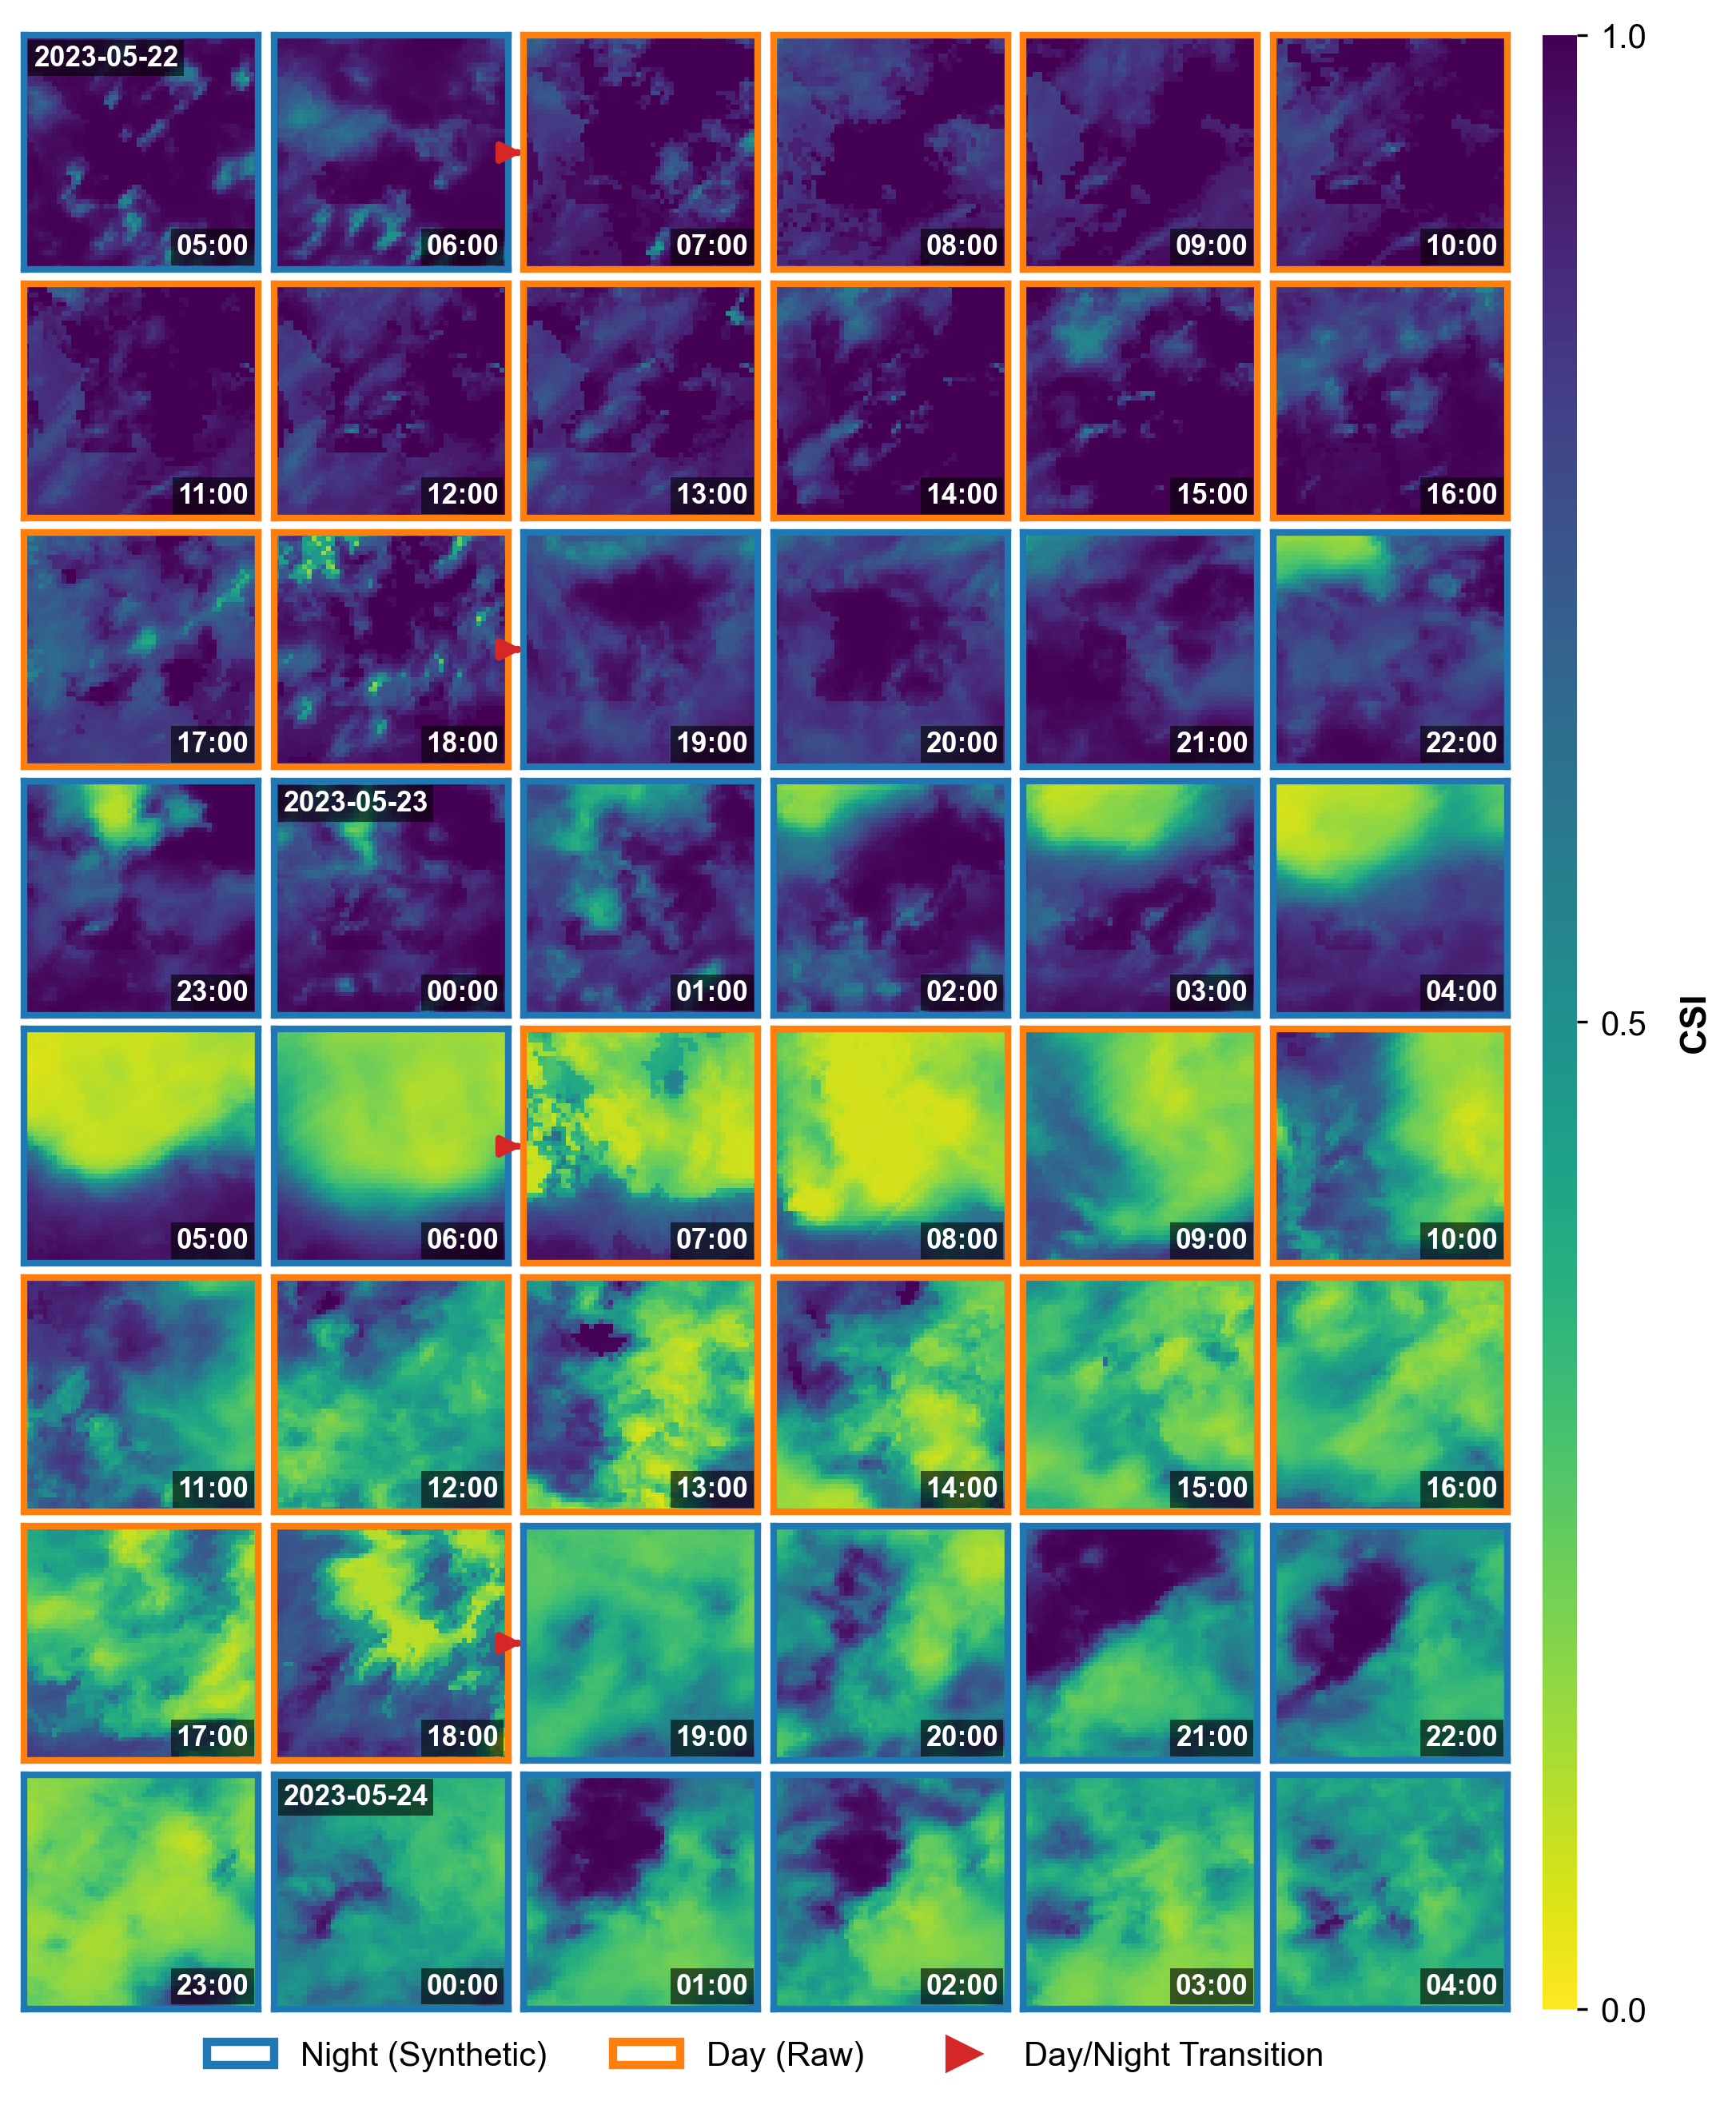

In [19]:
plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)
# plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)

## 5. Visual Verification

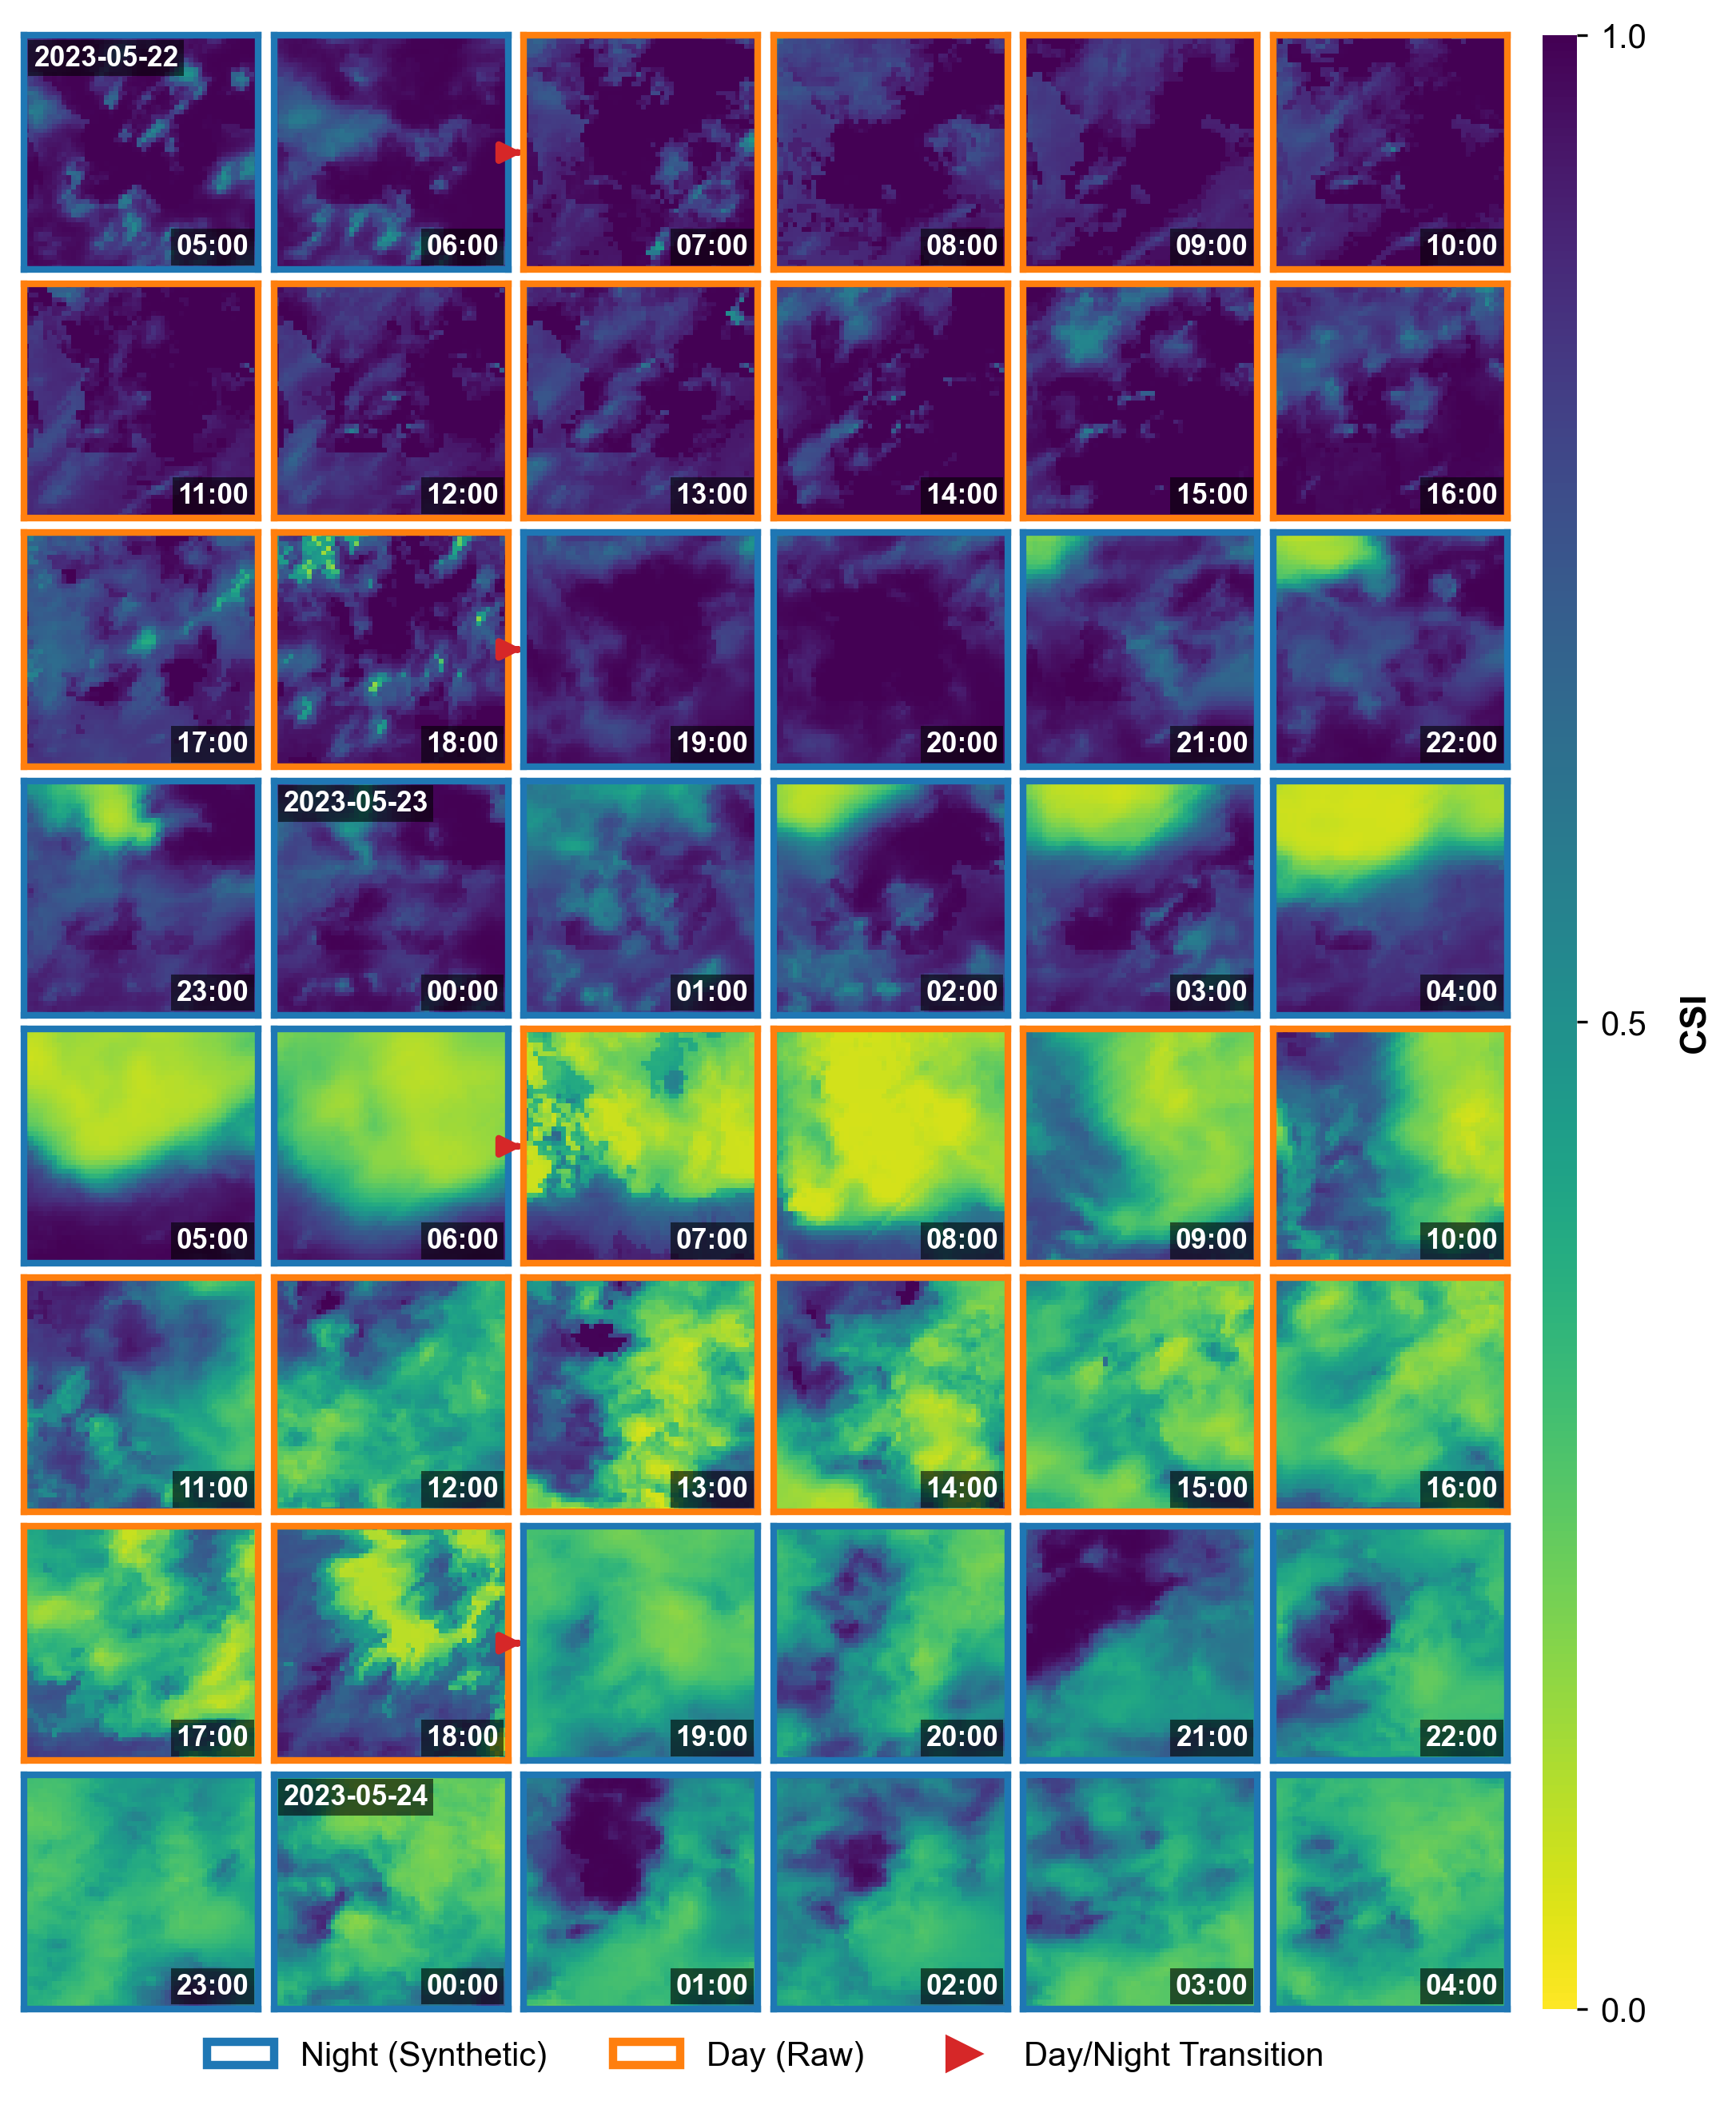

In [15]:
plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)

In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compare_csi_npz(path1, path2):
    print(f"Comparing:\n1: {path1}\n2: {path2}\n" + "-"*50)
    
    # 1. Load files
    data1 = np.load(path1)
    data2 = np.load(path2)
    
    # Check if keys match
    if set(data1.files) != set(data2.files):
        print(f"⚠️ Key mismatch! \nFile 1 keys: {data1.files}\nFile 2 keys: {data2.files}")
    
    csi1, time1 = data1['csi'], data1['time_hourly']
    csi2, time2 = data2['csi'], data2['time_hourly']
    
    # 2. Check Shapes
    print(f"Shape Comparison:")
    print(f"File 1 CSI: {csi1.shape} | Time: {time1.shape}")
    print(f"File 2 CSI: {csi2.shape} | Time: {time2.shape}")
    
    if csi1.shape != csi2.shape:
        print("❌ Shapes do not match! Cannot perform element-wise comparison.")
        return

    # 3. Check Temporal Alignment
    time_diff = np.sum(time1 != time2)
    if time_diff == 0:
        print("✅ Timestamps: Perfect match.")
    else:
        print(f"❌ Timestamps: {time_diff} indices differ.")

    # 4. Numerical Similarity (Stats)
    # We flatten the spatial dimensions to treat it as one big vector
    c1_flat = csi1.flatten()
    c2_flat = csi2.flatten()
    
    # Mask out NaNs if any exist to avoid breaking stats
    mask = ~np.isnan(c1_flat) & ~np.isnan(c2_flat)
    c1_clean = c1_flat[mask]
    c2_clean = c2_flat[mask]

    mae = mean_absolute_error(c1_clean, c2_clean)
    rmse = np.sqrt(mean_squared_error(c1_clean, c2_clean))
    correlation = np.corrcoef(c1_clean, c2_clean)[0, 1]
    max_diff = np.max(np.abs(c1_clean - c2_clean))
    
    print(f"\nNumeric Similarity Results:")
    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Sq. Error (RMSE): {rmse:.6f}")
    print(f"Pearson Correlation:      {correlation:.6f}")
    print(f"Max Pointwise Difference: {max_diff:.6f}")
    
    if mae == 0 and max_diff == 0:
        print("\n💎 Result: The two files are IDENTICAL.")
    elif correlation > 0.99:
        print("\n📈 Result: The files are HIGHLY similar (likely minor floating point diffs or tiny prep changes).")
    else:
        print("\n📉 Result: The files have significant differences.")

# Usage:
compare_csi_npz("Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz", "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz")

Comparing:
1: Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz
2: Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz
--------------------------------------------------
Shape Comparison:
File 1 CSI: (26104, 1, 50, 50) | Time: (26104,)
File 2 CSI: (26104, 1, 50, 50) | Time: (26104,)
✅ Timestamps: Perfect match.

Numeric Similarity Results:
Mean Absolute Error (MAE): 0.029868
Root Mean Sq. Error (RMSE): 0.063721
Pearson Correlation:      0.979036
Max Pointwise Difference: 0.897481

📉 Result: The files have significant differences.


Rank  | Timestamp (UTC)      | Max Diff   | Idx   
--------------------------------------------------
#1    | 2023-06-07 19:00:00+00:00 | 0.9040     | 21162 
#2    | 2021-05-25 21:00:00+00:00 | 0.8375     | 3441  
#3    | 2022-03-26 12:00:00+00:00 | 0.8335     | 10710 
#4    | 2021-01-15 22:00:00+00:00 | 0.8210     | 343   
#5    | 2023-07-29 12:00:00+00:00 | 0.8021     | 22396 
#6    | 2021-10-09 18:00:00+00:00 | 0.7921     | 6710  
#7    | 2023-06-25 21:00:00+00:00 | 0.7890     | 21592 
#8    | 2022-08-08 15:00:00+00:00 | 0.7848     | 13931 
#9    | 2021-01-15 21:00:00+00:00 | 0.7846     | 342   
#10   | 2021-07-20 17:00:00+00:00 | 0.7764     | 4776  


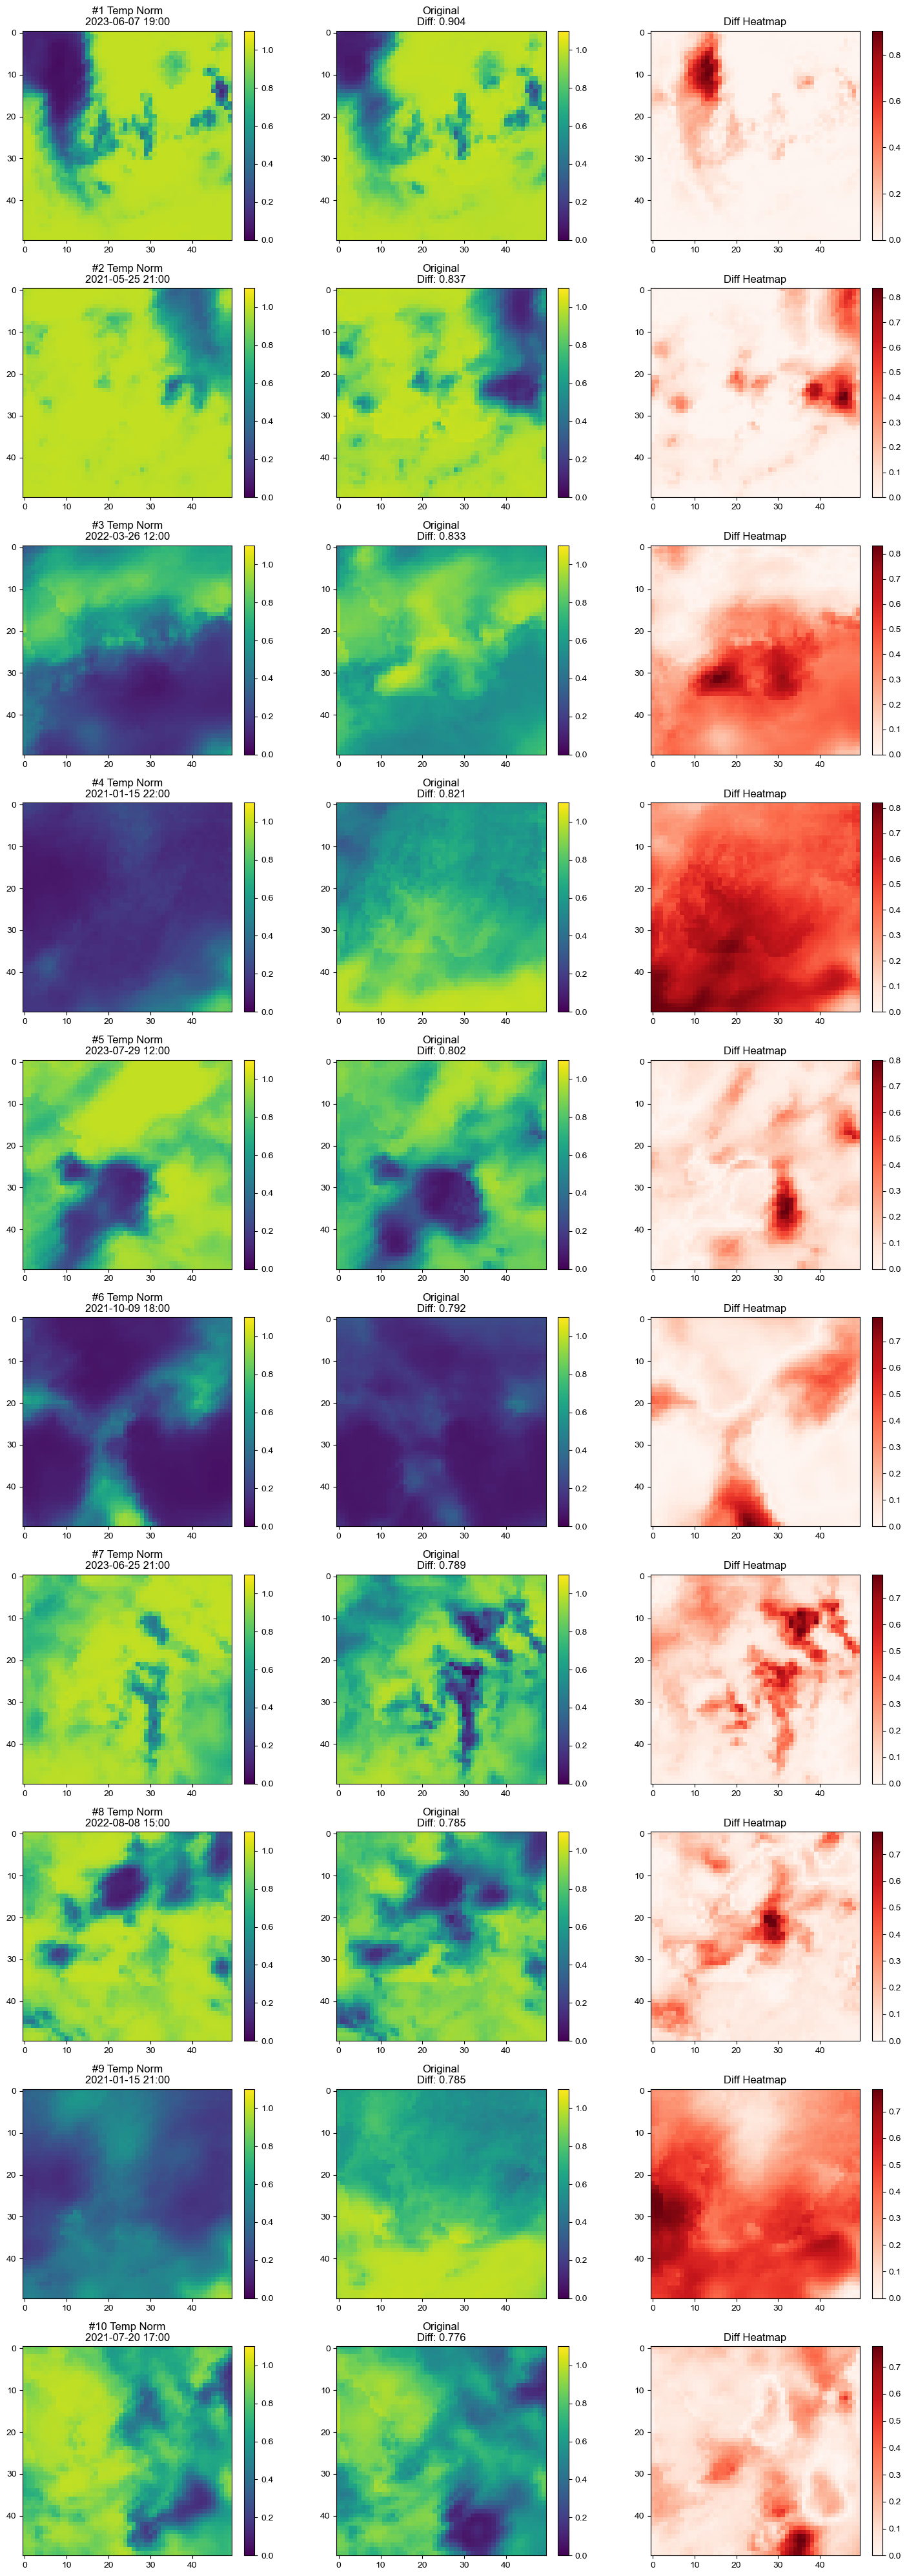

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def show_top_10_differences(path1, path2):
    # 1. Load data
    data1 = np.load(path1)
    data2 = np.load(path2)
    
    csi1 = data1['csi']
    csi2 = data2['csi']
    times = data1['time_hourly']
    
    # 2. Calculate pointwise absolute difference
    # Shape: (T, 1, 50, 50)
    diff = np.abs(csi1 - csi2)
    
    # 3. Find max difference in each frame
    # We flatten the spatial dims to find the peak error per time step
    max_err_per_frame = np.max(diff, axis=(1, 2, 3))
    
    # 4. Get the indices of the top 10 largest differences (sorted descending)
    top_10_idx = np.argsort(max_err_per_frame)[-10:][::-1]
    
    print(f"{'Rank':<5} | {'Timestamp (UTC)':<20} | {'Max Diff':<10} | {'Idx':<6}")
    print("-" * 50)

    # 5. Plotting loop
    fig, axes = plt.subplots(10, 3, figsize=(15, 40))
    
    for i, idx in enumerate(top_10_idx):
        ts = pd.to_datetime(times[idx], unit='h', utc=True)
        max_val = max_err_per_frame[idx]
        
        print(f"#{i+1:<4} | {str(ts):<20} | {max_val:.4f}     | {idx:<6}")
        
        # Column 1: Temp Normalized
        im1 = axes[i, 0].imshow(csi1[idx, 0], vmin=0, vmax=1.1, cmap='viridis')
        axes[i, 0].set_title(f"#{i+1} Temp Norm\n{ts.strftime('%Y-%m-%d %H:%M')}")
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)
        
        # Column 2: Original
        im2 = axes[i, 1].imshow(csi2[idx, 0], vmin=0, vmax=1.1, cmap='viridis')
        axes[i, 1].set_title(f"Original\nDiff: {max_val:.3f}")
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)
        
        # Column 3: Difference Heatmap
        im3 = axes[i, 2].imshow(diff[idx, 0], cmap='Reds', vmin=0, vmax=max_val)
        axes[i, 2].set_title("Diff Heatmap")
        plt.colorbar(im3, ax=axes[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Execution
path_norm = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
path_orig = "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz"

show_top_10_differences(path_norm, path_orig)

In [35]:
cams = np.load("Data/CAMS/csi_cams_hourly_pred_2021_2023.npz")

In [ ]:
import numpy as np
import pandas as pd

def audit_synthetic_npz(file_path):
    # 1. Load the data
    data = np.load(file_path)
    csi = data['csi']
    t_raw = data['time_hourly']
    
    # 2. Check for NaNs
    nan_count = np.isnan(csi).sum()
    nan_indices = np.unique(np.where(np.isnan(csi))[0])
    
    # 3. Check for Gaps in the Timeline
    # Convert raw hours to a sorted DatetimeIndex
    t_dt = pd.to_datetime(t_raw, unit='h', utc=True).sort_values()
    
    # Create the 'perfect' range from start to end (no gaps)
    ideal_range = pd.date_range(start=t_dt.min(), end=t_dt.max(), freq='h', tz='UTC')
    
    # Find which hours are in the ideal range but missing from your file
    gaps = ideal_range.difference(t_dt)
    
    # 4. Report Results
    print(f"--- Audit Report: {file_path.split('/')[-1]} ---")
    print(f"Total Samples: {len(t_raw)}")
    print("-" * 50)
    
    # NaN Results
    if nan_count == 0:
        print("✅ NaNs: None found. The CSI data is numerically clean.")
    else:
        print(f"❌ NaNs Found: {nan_count} total NaN values.")
        print(f"   Affected Samples: {len(nan_indices)} out of {len(t_raw)}")
        
    # Gap Results
    if len(gaps) == 0:
        print("✅ Gaps: None found. The hourly sequence is perfectly continuous.")
    else:
        print(f"❌ Gaps Found: {len(gaps)} hours are missing from the sequence.")
        print(f"   Continuity: {((len(t_raw) / len(ideal_range)) * 100):.2f}% coverage")
        
        if len(gaps) > 0:
            print("\nFirst 5 gaps (UTC):")
            for g in gaps[:5]:
                print(f"  - {g}")

# Execution
file_path = "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz"
audit_synthetic_npz(file_path)

--- Audit Report: csi_synthetic_hourly_merged_day_night_fuzzy.npz ---
Total Samples: 26104
--------------------------------------------------
✅ NaNs: None found. The CSI data is numerically clean.
❌ Gaps Found: 165 hours are missing from the sequence.
   Continuity: 99.37% coverage

First 5 gaps (UTC):
  - 2021-01-06 11:00:00+00:00
  - 2021-01-10 09:00:00+00:00
  - 2021-01-14 21:00:00+00:00
  - 2021-01-15 09:00:00+00:00
  - 2021-01-16 11:00:00+00:00


In [42]:
import numpy as np
import pandas as pd

def check_cams_gaps(file_path):
    # 1. Load the data
    data = np.load(file_path)
    
    # Identify the time key (usually 'time' or 'time_hourly')
    time_key = 'time_hourly' if 'time_hourly' in data.files else 'time'
    t_raw = data[time_key]
    
    print(f"--- Gap Analysis: {file_path.split('/')[-1]} ---")
    print(f"Total samples found: {len(t_raw)}")

    # 2. Convert to Datetime and Sort
    # The 'utc=True' is important for consistency with your other files
    t_dt = pd.to_datetime(t_raw, utc=True).sort_values()
    
    # 3. Define the continuous range (No Gaps)
    start_time = t_dt.min()
    end_time = t_dt.max()
    ideal_range = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC')
    
    # 4. Calculate Gaps
    # We use sets for a clean comparison
    actual_set = set(t_dt)
    ideal_set = set(ideal_range)
    
    missing_hours = sorted(list(ideal_set - actual_set))
    
    # 5. Report Results
    gap_count = len(missing_hours)
    
    if gap_count == 0:
        print("✅ Continuity: This file is a perfectly continuous hourly sequence.")
    else:
        print(f"❌ Gaps Found: {gap_count} missing hours.")
        print(f"   Time Range: {start_time} to {end_time}")
        print(f"   Coverage:   {(len(t_dt) / len(ideal_range) * 100):.2f}%")
        
        # Display the first few gaps to see if they are clustered
        print("\nFirst 10 missing timesteps (UTC):")
        for g in missing_hours[:10]:
            print(f"  - {g}")
            
        # Check for large blocks
        df_missing = pd.Series(missing_hours)
        if len(df_missing) > 1:
            diffs = df_missing.diff()
            large_gaps = diffs[diffs > pd.Timedelta(hours=1)]
            if not large_gaps.empty:
                print(f"\n⚠️ Alert: Found {len(large_gaps)} significant jump(s) in the timeline.")

# Run the check
path_cams = "Data/CAMS/csi_cams_hourly_pred_2021_2023.npz"
check_cams_gaps(path_cams)

--- Gap Analysis: csi_cams_hourly_pred_2021_2023.npz ---
Total samples found: 26269
✅ Continuity: This file is a perfectly continuous hourly sequence.


In [5]:
import numpy as np
import pandas as pd

def generate_chronological_continuity_table(
    raw_npz_path, 
    syn_npz_path, 
    target_channel=2
):
    """
    Calculates MASC using strictly partitioned HKT transitions.
    Guarantees Raw Nighttime CSI step changes equal exactly 0.0000.
    """
    print("⏳ Loading datasets...")
    raw_npz = np.load(raw_npz_path)
    time_utc = raw_npz["time"]
    raw_csi = raw_npz["data"][:, target_channel, :, :]  

    syn_npz = np.load(syn_npz_path)
    syn_csi = syn_npz["data"][:, target_channel, :, :]

    # 1. Convert to HKT and extract the hour
    print("🕒 Converting to HKT and mapping explicit chronological bounds...")
    time_hkt = pd.to_datetime(time_utc) + pd.Timedelta(hours=8)
    hours_hkt = time_hkt.hour 

    # 2. Identify strictly contiguous 1-hour frame pairs
    time_diffs_mins = np.diff(time_utc).astype('timedelta64[m]').astype(int)
    valid_contiguous_mask = (time_diffs_mins == 60)

    # 3. PERFECTLY MUTUALLY EXCLUSIVE 24-HOUR BUCKETING
    # We evaluate the destination hour (t+1) to classify the transition.
    target_hours = hours_hkt[1:]

    phases = {
        # Transitions strictly within the day (t=8..15 -> t+1=9..16) [8 pairs/day]
        "Daytime Core": np.isin(target_hours, [9, 10, 11, 12, 13, 14, 15, 16]) & valid_contiguous_mask,
        
        # Transitions strictly within the night (t=20..4 -> t+1=21..5) [9 pairs/day]
        "Nighttime Core": np.isin(target_hours, [21, 22, 23, 0, 1, 2, 3, 4, 5]) & valid_contiguous_mask,
        
        # Transitions entering/crossing dawn (t=5..7 -> t+1=6..8) [3 pairs/day]
        "Dawn (Night -> Day)": np.isin(target_hours, [6, 7, 8]) & valid_contiguous_mask,
        
        # Transitions entering/crossing dusk (t=16..19 -> t+1=17..20) [4 pairs/day]
        "Dusk (Day -> Night)": np.isin(target_hours, [17, 18, 19, 20]) & valid_contiguous_mask
    }

    # 4. Compute Metrics for Each Phase
    results = []
    print("📊 Computing kinematic stability metrics...")

    for phase_name, mask in phases.items():
        idx_t = np.where(mask)[0]
        idx_t1 = idx_t + 1
        
        total_pairs = len(idx_t)
        if total_pairs == 0:
            continue
            
        # Calculate pixel-wise absolute step change for the entire spatial grid, then take the spatial mean
        raw_step_changes = np.mean(np.abs(raw_csi[idx_t1] - raw_csi[idx_t]), axis=(1, 2))
        syn_step_changes = np.mean(np.abs(syn_csi[idx_t1] - syn_csi[idx_t]), axis=(1, 2))

        # Calculate Mean (mu) and Standard Deviation (sigma)
        raw_mu, raw_sigma = np.mean(raw_step_changes), np.std(raw_step_changes)
        syn_mu, syn_sigma = np.mean(syn_step_changes), np.std(syn_step_changes)

        results.append({
            "Transition Phase": phase_name,
            "Pairs (N)": total_pairs,
            "Raw CSI Track": f"{raw_mu:.4f} ± {raw_sigma:.4f}",
            "Synthetic CSI Track": f"{syn_mu:.4f} ± {syn_sigma:.4f}"
        })

    df_results = pd.DataFrame(results)
    
    # 5. Print Results
    print("\n" + "="*80)
    print("🏆 ADVANCED KINEMATIC CONTINUITY ANALYSIS")
    print("="*80)
    print(df_results.to_string(index=False))
    
    return df_results

if __name__ == "__main__":
    RAW_PATH = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
    SYN_PATH = "Data/CAMS/csi_synthetic_cams_clone.npz"
    
    df = generate_chronological_continuity_table(RAW_PATH, SYN_PATH)

⏳ Loading datasets...
🕒 Converting to HKT and mapping explicit chronological bounds...
📊 Computing kinematic stability metrics...

🏆 ADVANCED KINEMATIC CONTINUITY ANALYSIS
   Transition Phase  Pairs (N)   Raw CSI Track Synthetic CSI Track
       Daytime Core       8752 0.1107 ± 0.0710     0.1107 ± 0.0710
     Nighttime Core       9855 0.0000 ± 0.0000     0.1097 ± 0.1067
Dawn (Night -> Day)       3284 0.3453 ± 0.3483     0.1319 ± 0.0969
Dusk (Day -> Night)       4377 0.2678 ± 0.3329     0.1138 ± 0.0896


⏳ Loading datasets...
🕒 Computing hour-to-hour step changes...
📈 Generating visualization...
✅ Plot saved successfully to 'csi_hourly_step_change_24h.pdf'!


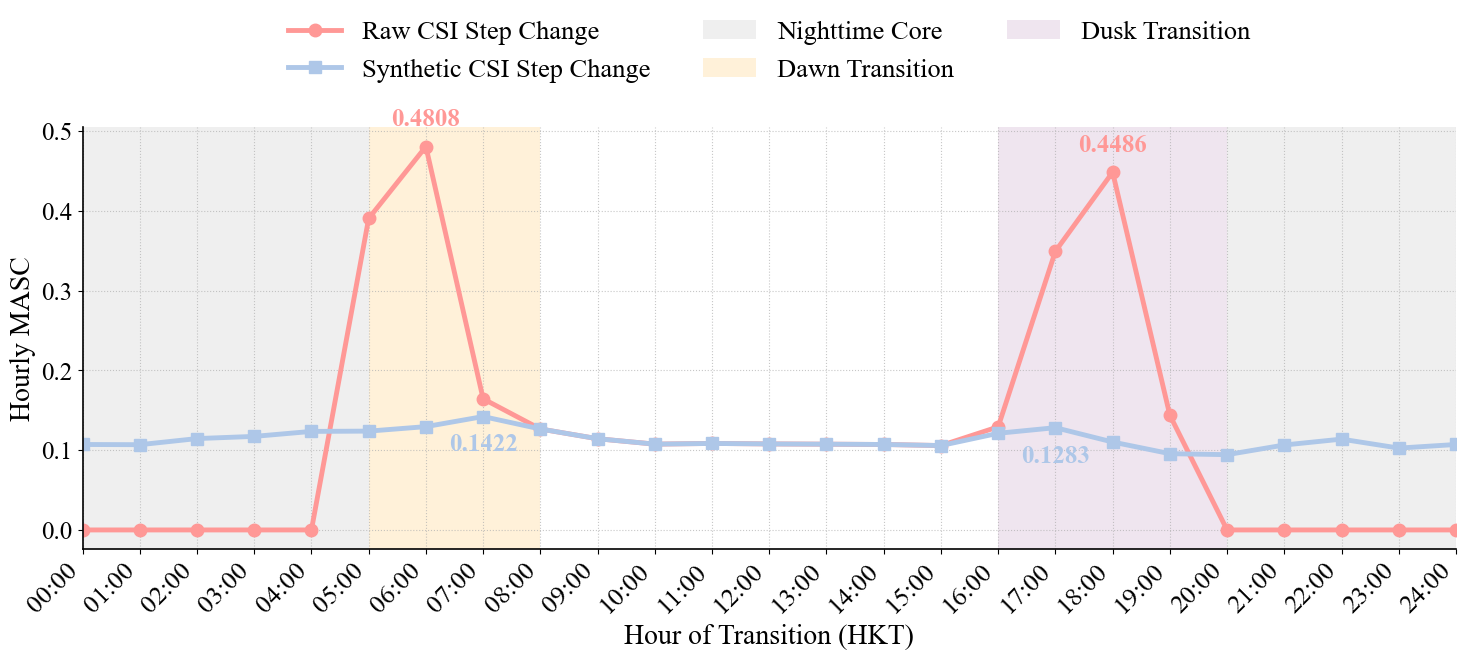

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_publication_step_change(
    raw_npz_path, 
    syn_npz_path, 
    target_channel=2, 
    save_path='csi_hourly_step_change_24h.pdf'
):
    # 1. Publication Styling
    plt.rcParams.update({
        'font.size': 18,
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix',
        'axes.linewidth': 1.2,
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })
    
    # 2. User-Assigned Colors
    c_raw = '#ff9896'  # Pastel Red
    c_syn = '#aec7e8'  # Pastel Blue

    print("⏳ Loading datasets...")
    raw_npz = np.load(raw_npz_path)
    time_utc = raw_npz["time"]
    raw_csi = raw_npz["data"][:, target_channel, :, :]  

    syn_npz = np.load(syn_npz_path)
    syn_csi = syn_npz["data"][:, target_channel, :, :]

    # 3. Convert to HKT and identify transitions
    print("🕒 Computing hour-to-hour step changes...")
    time_hkt = pd.to_datetime(time_utc) + pd.Timedelta(hours=8)
    
    # The start hour of the transition (hour t)
    start_hours_hkt = time_hkt.hour[:-1] 

    time_diffs_mins = np.diff(time_utc).astype('timedelta64[m]').astype(int)
    valid_mask = (time_diffs_mins == 60)

    # 4. Compute absolute step changes across the spatial grid
    raw_step = np.mean(np.abs(raw_csi[1:] - raw_csi[:-1]), axis=(1, 2))
    syn_step = np.mean(np.abs(syn_csi[1:] - syn_csi[:-1]), axis=(1, 2))

    df = pd.DataFrame({
        'Start_Hour': start_hours_hkt[valid_mask],
        'Raw_Step': raw_step[valid_mask],
        'Syn_Step': syn_step[valid_mask]
    })

    # Group by the 24 distinct hours to get the exact average step change
    hourly_means = df.groupby('Start_Hour').mean().reset_index()

    # 5. Map X-axis directly to standard 24-hour time (00:00 to 23:00)
    hourly_means['Plot_X'] = hourly_means['Start_Hour']
    hourly_means = hourly_means.sort_values('Plot_X').reset_index(drop=True)

    # Close the loop visually by appending 00:00 as 24:00 at the end
    hourly_means.loc[24] = hourly_means.iloc[0]
    hourly_means.at[24, 'Plot_X'] = 24

    # 6. Plotting
    print("📈 Generating visualization...")
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Plot curves
    ax.plot(hourly_means['Plot_X'], hourly_means['Raw_Step'], 
             color=c_raw, linewidth=3.5, marker='o', markersize=9, label='Raw CSI Step Change')
    ax.plot(hourly_means['Plot_X'], hourly_means['Syn_Step'], 
             color=c_syn, linewidth=3.5, marker='s', markersize=9, label='Synthetic CSI Step Change')

    # 7. Distinct Shaded Regions on EXACT Whole Hours
    # These match the exact contiguous intervals from your continuity table:
    # Night: 20:00 to 05:00 (Wraps around 00:00)
    ax.axvspan(0, 5, color='#cccccc', alpha=0.3, lw=0)
    ax.axvspan(20, 24, color='#cccccc', alpha=0.3, lw=0, label='Nighttime Core')
    
    # Dawn: 05:00 to 08:00
    ax.axvspan(5, 8, color='#ffe5b4', alpha=0.5, lw=0, label='Dawn Transition')
    
    # Dusk: 16:00 to 20:00
    ax.axvspan(16, 20, color='#d8bfd8', alpha=0.4, lw=0, label='Dusk Transition')

    # 8. Exact Data Annotations (Dynamic Extraction within strict boundaries)
    # DAWN PEAKS (Start hours 5, 6, 7)
    dawn_window = hourly_means[(hourly_means['Plot_X'] >= 5) & (hourly_means['Plot_X'] <= 7)]
    raw_dawn_peak = dawn_window.loc[dawn_window['Raw_Step'].idxmax()]
    syn_dawn_peak = dawn_window.loc[dawn_window['Syn_Step'].idxmax()]
    
    ax.annotate(f"{raw_dawn_peak['Raw_Step']:.4f}", 
                xy=(raw_dawn_peak['Plot_X'], raw_dawn_peak['Raw_Step']), 
                xytext=(0, 15), textcoords='offset points', ha='center', color=c_raw, fontweight='bold')
    
    ax.annotate(f"{syn_dawn_peak['Syn_Step']:.4f}", 
                xy=(syn_dawn_peak['Plot_X'], syn_dawn_peak['Syn_Step']), 
                xytext=(0, -25), textcoords='offset points', ha='center', color=c_syn, fontweight='bold')

    # DUSK PEAKS (Start hours 16, 17, 18, 19)
    dusk_window = hourly_means[(hourly_means['Plot_X'] >= 16) & (hourly_means['Plot_X'] <= 19)]
    raw_dusk_peak = dusk_window.loc[dusk_window['Raw_Step'].idxmax()]
    syn_dusk_peak = dusk_window.loc[dusk_window['Syn_Step'].idxmax()]
    
    ax.annotate(f"{raw_dusk_peak['Raw_Step']:.4f}", 
                xy=(raw_dusk_peak['Plot_X'], raw_dusk_peak['Raw_Step']), 
                xytext=(0, 15), textcoords='offset points', ha='center', color=c_raw, fontweight='bold')
    
    ax.annotate(f"{syn_dusk_peak['Syn_Step']:.4f}", 
                xy=(syn_dusk_peak['Plot_X'], syn_dusk_peak['Syn_Step']), 
                xytext=(0, -25), textcoords='offset points', ha='center', color=c_syn, fontweight='bold')

    # 9. Formatting the Axes
    ax.set_ylabel('Hourly MASC', fontsize=20)
    ax.set_xlabel('Hour of Transition (HKT)', fontsize=20)
    
    # Standard 24-hour ticks
    x_labels = [f"{h:02d}:00" for h in range(25)]
    ax.set_xticks(np.arange(25))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=19)
    ax.set_xlim(0, 24)
    
    # Clean up the look
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # ✅ FIXED: Positioned legend completely outside on top with a 3, 2 arrangement
    ax.legend(
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.05), 
        frameon=False, 
        fontsize=19, 
        ncol=3
    )
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"✅ Plot saved successfully to '{save_path}'!")

if __name__ == "__main__":
    RAW_PATH = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
    SYN_PATH = "Data/CAMS/csi_synthetic_cams_clone.npz"
    
    plot_publication_step_change(RAW_PATH, SYN_PATH)